In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
print("Loading test data...")
test_data = pd.read_csv('employee.csv')

# Display basic information about the dataset
print("\nTest data shape:", test_data.shape)
print("\nFirst few rows of the test data:")
display(test_data.head())

Loading test data...

Test data shape: (4277, 13)

First few rows of the test data:


,id,timestamp,country,employment_status,job_title,job_years,is_manager,hours_per_week,telecommute_days_per_week,education,is_education_computer_related,certifications,salary
0,1,12/11/2018 10:52:26,Slovenia,Full time,Developer,4.78393,Yes,40.0,0.0,Bachelors (4 years),Yes,No,7187.743094
1,2,1/5/2017 16:57:50,United States,Full time,DBA,5.00000,No,40.0,5.0,Bachelors (4 years),Yes,No,10000.000000
2,3,12/18/2017 8:13:15,Sweden,Full time,DBA,1.00000,No,40.0,0.0,Masters,Yes,Yes,7000.000000
3,4,12/27/2018 4:56:52,United States,Full time,DBA,1.00000,No,40.0,2.0,Bachelors (4 years),No,No,8333.000000
4,5,12/11/2018 14:07:58,United States,Full time,Developer,3.00000,No,40.0,2.0,Masters,Yes,Yes,7137.000000



Basic statistics of numerical columns:


,id,job_years,hours_per_week,telecommute_days_per_week,salary
count,4277.00000,4277.000000,4260.000000,4266.000000,4277.000000
mean,2139.00000,4.479697,40.859110,1.034927,7057.701984
std,1234.80788,1.990783,1.754911,1.651160,1308.572568
min,1.00000,0.000000,37.000000,0.000000,3622.000000
25%,1070.00000,3.407156,40.000000,0.000000,6496.788236
50%,2139.00000,4.640830,40.000000,0.000000,7166.000000
75%,3208.00000,5.000000,41.114138,1.000000,7614.831964
max,4277.00000,10.000000,45.000000,5.000000,10625.000000



Missing values in each column:


id                                0
timestamp                         0
country                           0
employment_status                 0
job_title                         0
job_years                         0
is_manager                        0
hours_per_week                   17
telecommute_days_per_week        11
education                         0
is_education_computer_related    16
certifications                    0
salary                            0
dtype: int64

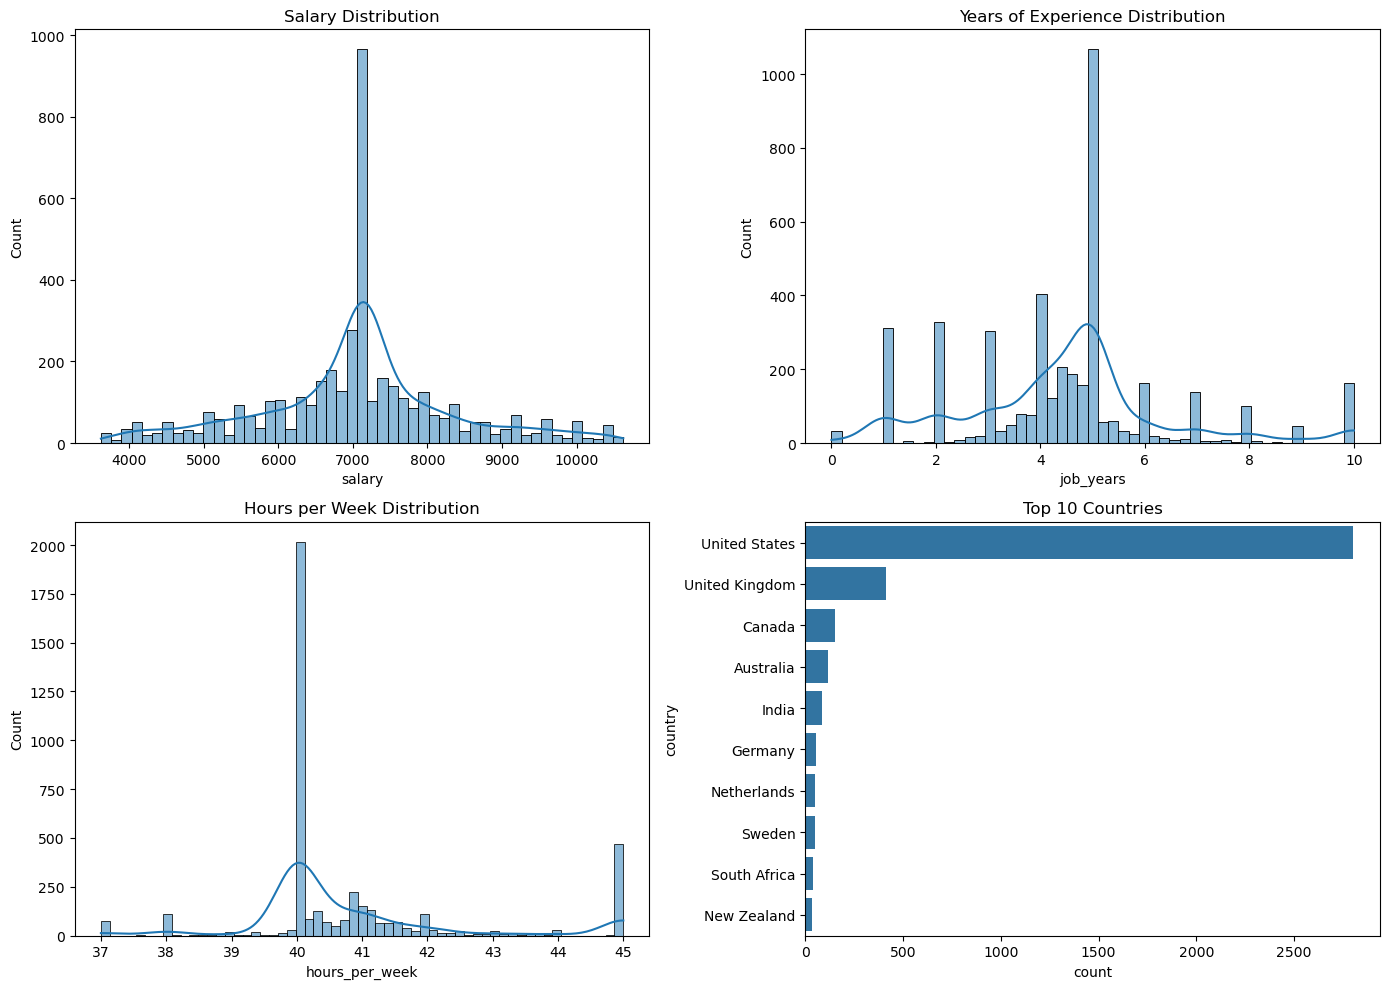

In [3]:

print("\nBasic statistics of numerical columns:")
display(test_data.describe())

print("\nMissing values in each column:")
display(test_data.isnull().sum())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(test_data['salary'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Salary Distribution')

sns.histplot(test_data['job_years'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Years of Experience Distribution')

sns.histplot(test_data['hours_per_week'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Hours per Week Distribution')

sns.countplot(y='country', data=test_data, order=test_data['country'].value_counts().index[:10], ax=axes[1, 1])
axes[1, 1].set_title('Top 10 Countries')

plt.tight_layout()
plt.show()

In [4]:
numerical_features = ['job_years', 'hours_per_week', 'telecommute_days_per_week']
categorical_features = ['country', 'employment_status', 'job_title', 'is_manager', 
                        'education', 'is_education_computer_related', 'certifications']


print("Setting up preprocessing pipeline...")
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

Setting up preprocessing pipeline...
